Shape X : (4000, 12)
Shape y : (4000,)

✅ Modèle entraîné
Nombre de paramètres : 13

📊 Performances du modèle
MSE  : 0.08065607437961315
RMSE : 0.284000130949993
R²   : 0.3682701087704613


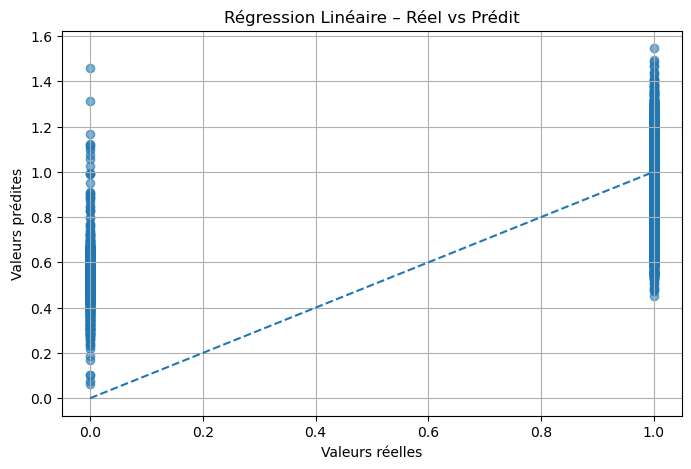


📌 Importance des variables :
                   Variable  Coefficient
0                     Biais    -0.599488
7               final_score     0.008568
6             midterm_score     0.006516
5           assignments_avg     0.006277
9        lab_hours_per_week    -0.004170
11    extracurricular_count     0.002603
3           attendance_rate     0.001508
8     project_participation     0.001272
1                       age    -0.000630
4              num_absences     0.000096
2             year_of_study     0.000083
12           promotion_size    -0.000055
10  infra_usage_hours_month     0.000035


In [2]:
# ======================================================
# REGRESSION LINEAIRE - MOINDRES CARRES (FROM SCRATCH)
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------
# 1️⃣ Chargement des données
# ------------------------------------------------
X = pd.read_csv("X_train.csv")
y = pd.read_csv("y_train.csv").values.ravel()

# Garder uniquement les colonnes numériques
X = X.select_dtypes(include=[np.number]).fillna(0)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

# ------------------------------------------------
# 2️⃣ Ajout du biais (colonne de 1)
# ------------------------------------------------
m = X.shape[0]
X_np = X.values
X_b = np.c_[np.ones((m, 1)), X_np]

# ------------------------------------------------
# 3️⃣ Entraînement du modèle (équation normale)
# θ = (XᵀX)⁻¹ Xᵀy
# ------------------------------------------------
theta = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y

print("\n✅ Modèle entraîné")
print("Nombre de paramètres :", len(theta))

# ------------------------------------------------
# 4️⃣ Prédiction
# ------------------------------------------------
y_pred = X_b @ theta

# ------------------------------------------------
# 5️⃣ Évaluation du modèle (from scratch)
# ------------------------------------------------
mse = np.mean((y - y_pred) ** 2)
rmse = np.sqrt(mse)

# Coefficient de détermination R²
ss_total = np.sum((y - np.mean(y)) ** 2)
ss_res = np.sum((y - y_pred) ** 2)
r2 = 1 - (ss_res / ss_total)

print("\n📊 Performances du modèle")
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

# ------------------------------------------------
# 6️⃣ Visualisation : Réel vs Prédit
# ------------------------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], linestyle="--")
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Régression Linéaire – Réel vs Prédit")
plt.grid(True)
plt.show()

# ------------------------------------------------
# 7️⃣ Importance des variables (coefficients)
# ------------------------------------------------
coef_df = pd.DataFrame({
    "Variable": ["Biais"] + list(X.columns),
    "Coefficient": theta
}).sort_values(by="Coefficient", key=np.abs, ascending=False)

print("\n📌 Importance des variables :")
print(coef_df)


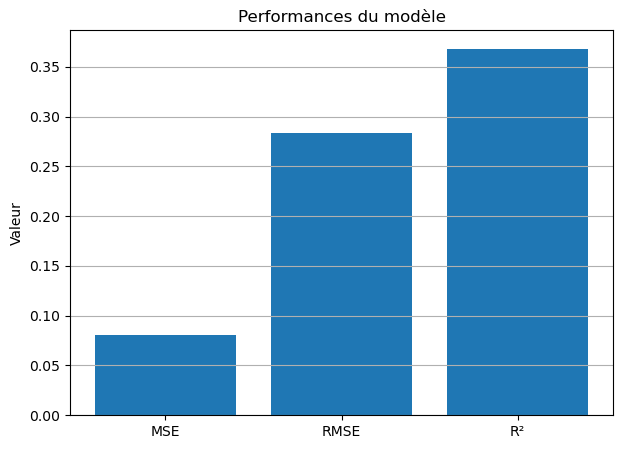

Fonction coût J(theta) = 0.04032803718980658


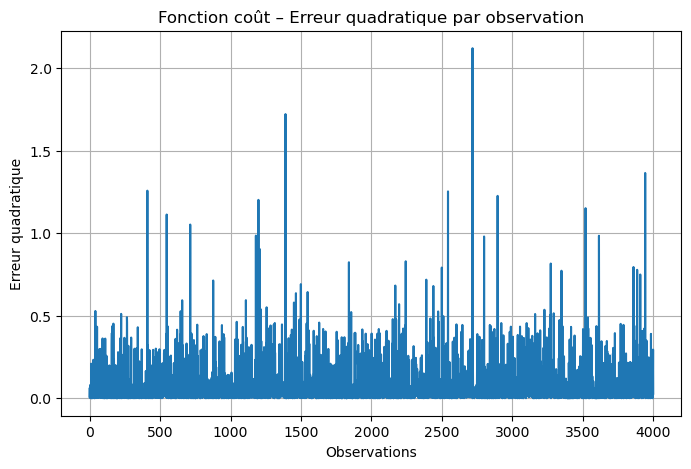

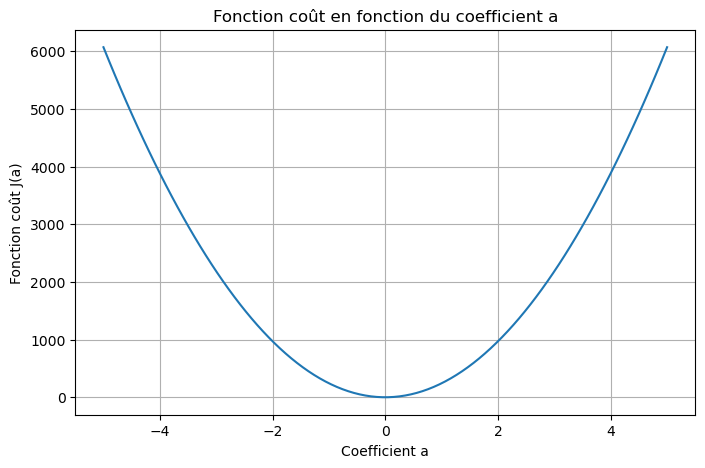

In [4]:
# ------------------------------------------------
# 8️⃣ Graphique des métriques d'évaluation
# ------------------------------------------------
metrics_names = ["MSE", "RMSE", "R²"]
metrics_values = [mse, rmse, r2]

plt.figure(figsize=(7, 5))
plt.bar(metrics_names, metrics_values)
plt.title("Performances du modèle")
plt.ylabel("Valeur")
plt.grid(axis="y")
plt.show()
# ------------------------------------------------
# 9️⃣ Fonction coût J(theta)(erreur quadratique)
# ------------------------------------------------
def cost_function(y_true, y_pred):
    m = len(y_true)
    return (1 / (2 * m)) * np.sum((y_true - y_pred) ** 2)

cost = cost_function(y, y_pred)

print("Fonction coût J(theta) =", cost)
# ------------------------------------------------
# 🔟 Courbe de la fonction coût (erreurs individuelles)
# ------------------------------------------------
errors = (y - y_pred) ** 2

plt.figure(figsize=(8, 5))
plt.plot(errors)
plt.xlabel("Observations")
plt.ylabel("Erreur quadratique")
plt.title("Fonction coût – Erreur quadratique par observation")
plt.grid(True)
plt.show()
# ------------------------------------------------
# 🔥 Fonction coût selon un paramètre (visualisation)
# ------------------------------------------------
a_values = np.linspace(theta[1] - 5, theta[1] + 5, 100)
cost_values = []

for a in a_values:
    theta_temp = theta.copy()
    theta_temp[1] = a
    y_temp = X_b @ theta_temp
    cost_values.append(cost_function(y, y_temp))

plt.figure(figsize=(8, 5))
plt.plot(a_values, cost_values)
plt.xlabel("Coefficient a")
plt.ylabel("Fonction coût J(a)")
plt.title("Fonction coût en fonction du coefficient a")
plt.grid(True)
plt.show()




✅ Modèle entraîné avec succès



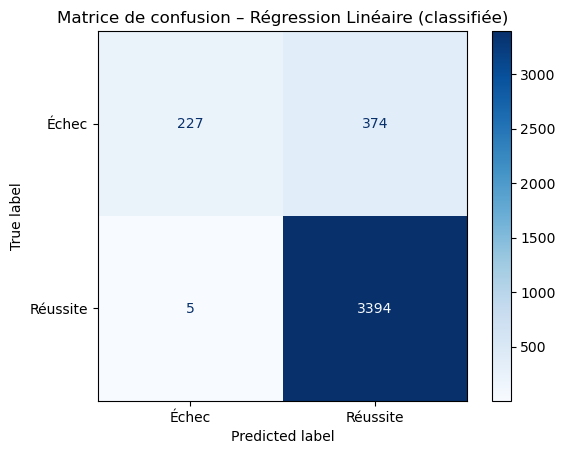

📊 Métriques de classification
Exactitude globale : 90.53%
Succès détectés : 99.85%
Faux négatifs : 0.15%

📊 Métriques de régression
MSE  : 0.08
RMSE : 0.28
R²   : 0.37

📌 Importance des variables :
               Variable  Coefficient
                  Biais    -0.599488
            final_score     0.008568
          midterm_score     0.006516
        assignments_avg     0.006277
     lab_hours_per_week    -0.004170
  extracurricular_count     0.002603
        attendance_rate     0.001508
  project_participation     0.001272
                    age    -0.000630
           num_absences     0.000096
          year_of_study     0.000083
         promotion_size    -0.000055
infra_usage_hours_month     0.000035


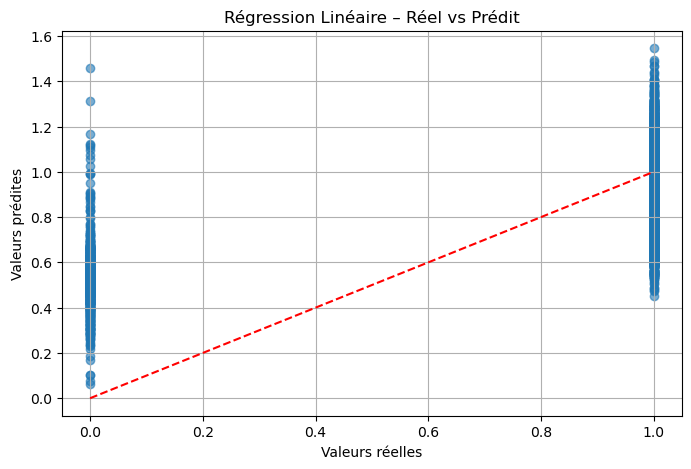

In [8]:
# ======================================================
# REGRESSION LINEAIRE AVEC MATRICE DE CONFUSION
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ------------------------------------------------
# 1️⃣ Chargement des données
# ------------------------------------------------
X = pd.read_csv("X_train.csv")
y = pd.read_csv("y_train.csv").values.ravel()

# Garder uniquement les colonnes numériques
X = X.select_dtypes(include=[np.number]).fillna(0)

# Ajouter un biais
m = X.shape[0]
X_np = X.values
X_b = np.c_[np.ones((m, 1)), X_np]

# ------------------------------------------------
# 2️⃣ Entraînement du modèle (équation normale)
# θ = (XᵀX)⁻¹ Xᵀy
# ------------------------------------------------
theta = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y
print("✅ Modèle entraîné avec succès\n")

# ------------------------------------------------
# 3️⃣ Prédiction continue
# ------------------------------------------------
y_pred = X_b @ theta

# ------------------------------------------------
# 4️⃣ Transformation en réussite/échec
# ------------------------------------------------
y_class = (y >= 0.5).astype(int)        # classes réelles
y_pred_class = (y_pred >= 0.5).astype(int)  # classes prédites

# ------------------------------------------------
# 5️⃣ Matrice de confusion
# ------------------------------------------------
cm = confusion_matrix(y_class, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Échec", "Réussite"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion – Régression Linéaire (classifiée)")
plt.show()

tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / cm.sum()
success_detected_rate = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
false_neg_rate = fn / (tp + fn) * 100 if (tp + fn) > 0 else 0

print("📊 Métriques de classification")
print(f"Exactitude globale : {accuracy*100:.2f}%")
print(f"Succès détectés : {success_detected_rate:.2f}%")
print(f"Faux négatifs : {false_neg_rate:.2f}%\n")

# ------------------------------------------------
# 6️⃣ Évaluation du modèle continu
# ------------------------------------------------
mse = np.mean((y - y_pred) ** 2)
rmse = np.sqrt(mse)
ss_total = np.sum((y - np.mean(y)) ** 2)
ss_res = np.sum((y - y_pred) ** 2)
r2 = 1 - (ss_res / ss_total)

print("📊 Métriques de régression")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}\n")

# ------------------------------------------------
# 7️⃣ Importance des variables
# ------------------------------------------------
coef_df = pd.DataFrame({
    "Variable": ["Biais"] + list(X.columns),
    "Coefficient": theta
}).sort_values(by="Coefficient", key=np.abs, ascending=False)

print("📌 Importance des variables :")
print(coef_df.to_string(index=False))

# ------------------------------------------------
# 8️⃣ Visualisation Réel vs Prédit
# ------------------------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], linestyle="--", color="red")
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Régression Linéaire – Réel vs Prédit")
plt.grid(True)
plt.show()



✅ Modèle entraîné avec succès



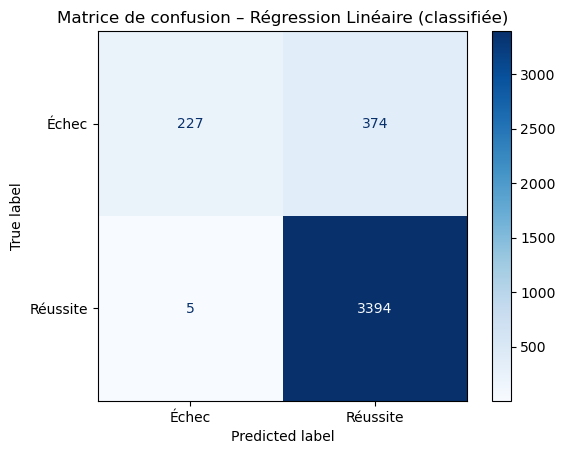

📊 Métriques de classification
Exactitude globale : 90.53%
Succès détectés : 99.85%
Faux négatifs : 0.15%

📊 Métriques de régression
MSE  : 0.08
RMSE : 0.28
R²   : 0.37

📌 Importance des variables :
               Variable  Coefficient
                  Biais    -0.599488
            final_score     0.008568
          midterm_score     0.006516
        assignments_avg     0.006277
     lab_hours_per_week    -0.004170
  extracurricular_count     0.002603
        attendance_rate     0.001508
  project_participation     0.001272
                    age    -0.000630
           num_absences     0.000096
          year_of_study     0.000083
         promotion_size    -0.000055
infra_usage_hours_month     0.000035


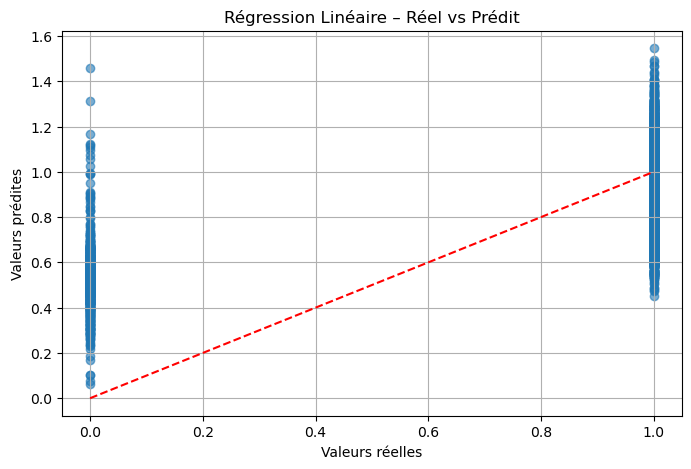

In [13]:
# ======================================================
# REGRESSION LINEAIRE AVEC MATRICE DE CONFUSION ET GRAPHIQUE DES COEFFICIENTS
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ------------------------------------------------
# 1️⃣ Chargement des données
# ------------------------------------------------
X = pd.read_csv("X_train.csv")
y = pd.read_csv("y_train.csv").values.ravel()

# Garder uniquement les colonnes numériques
X = X.select_dtypes(include=[np.number]).fillna(0)

# Ajouter un biais
m = X.shape[0]
X_np = X.values
X_b = np.c_[np.ones((m, 1)), X_np]

# ------------------------------------------------
# 2️⃣ Entraînement du modèle (équation normale)
# θ = (XᵀX)⁻¹ Xᵀy
# ------------------------------------------------
theta = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y
print("✅ Modèle entraîné avec succès\n")

# ------------------------------------------------
# 3️⃣ Prédiction continue
# ------------------------------------------------
y_pred = X_b @ theta

# ------------------------------------------------
# 4️⃣ Transformation en réussite/échec
# ------------------------------------------------
y_class = (y >= 0.5).astype(int)        # classes réelles
y_pred_class = (y_pred >= 0.5).astype(int)  # classes prédites

# ------------------------------------------------
# 5️⃣ Matrice de confusion
# ------------------------------------------------
cm = confusion_matrix(y_class, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Échec", "Réussite"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion – Régression Linéaire (classifiée)")
plt.show()

tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / cm.sum()
success_detected_rate = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
false_neg_rate = fn / (tp + fn) * 100 if (tp + fn) > 0 else 0

print("📊 Métriques de classification")
print(f"Exactitude globale : {accuracy*100:.2f}%")
print(f"Succès détectés : {success_detected_rate:.2f}%")
print(f"Faux négatifs : {false_neg_rate:.2f}%\n")

# ------------------------------------------------
# 6️⃣ Évaluation du modèle continu
# ------------------------------------------------
mse = np.mean((y - y_pred) ** 2)
rmse = np.sqrt(mse)
ss_total = np.sum((y - np.mean(y)) ** 2)
ss_res = np.sum((y - y_pred) ** 2)
r2 = 1 - (ss_res / ss_total)

print("📊 Métriques de régression")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}\n")

# ------------------------------------------------
# 7️⃣ Importance des variables
# ------------------------------------------------
coef_df = pd.DataFrame({
    "Variable": ["Biais"] + list(X.columns),
    "Coefficient": theta
}).sort_values(by="Coefficient", key=np.abs, ascending=False)

print("📌 Importance des variables :")
print(coef_df.to_string(index=False))




# ------------------------------------------------
# 8️⃣ Visualisation Réel vs Prédit
# ------------------------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], linestyle="--", color="red")
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Régression Linéaire – Réel vs Prédit")
plt.grid(True)
plt.show()


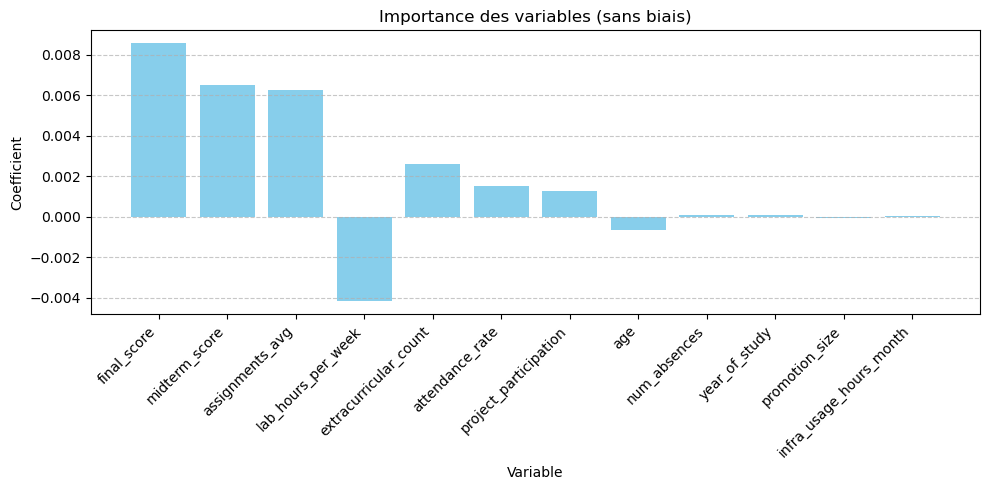

In [10]:
# Exclure le biais pour le graphique
coef_vars = coef_df[coef_df["Variable"] != "Biais"]
plt.figure(figsize=(10,5))
plt.bar(coef_vars["Variable"], coef_vars["Coefficient"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Variable")
plt.ylabel("Coefficient")
plt.title("Importance des variables (sans biais)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
